# LOAD LIBRARIES

In [172]:

import pandas as pd # pandas allows to do a lot of basic data manipulation such as loading csv data files
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt # matplotlib is a basic ploting library of Python
from scipy.stats import lognorm 
from pathlib import Path
from diive.core.io.files import save_parquet, load_parquet

# CONFIGS

In [173]:
start_date = '2023-11-17'
end_date = '2024-08-23'

Custom plotting function

In [174]:
def plot_data_grid(indat, ncols=3):
    vars = indat.columns
    nrows = (len(vars) + ncols - 1) // ncols  # Calculate the number of rows needed
    relative_markersize = max(1, 10 / len(vars))  # Scale marker size inversely to the number of plots
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows), constrained_layout=True)
    axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
    
    for ax, var in zip(axes, vars):
        ax.plot(indat[var], marker='o', markersize=relative_markersize, label=var)
        ax.set_xlabel('Time')
        ax.set_ylabel(var)
        ax.tick_params(axis='x', rotation=45)
        ax.legend()
    
    # Remove any unused subplots
    for ax in axes[len(vars):]:
        fig.delaxes(ax)
    
    plt.show()

# READ DATA

## FLUXES

Loaded .parquet file ../90_FINAL_MERGE/90.1_FLUXES_METEO_MGMT.parquet (0.568 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,FN2O_L3.3_CUT_50_QCF0,GPP_NT_CUT_50_gfXG_QCF,parcel,parcel_certainty
TIMESTAMP_MIDDLE,,,,
2023-11-17 00:15:00,-0.856583,0.127180,B,certain
2023-11-17 00:45:00,0.475557,0.051548,B,certain
2023-11-17 01:15:00,NaN,-0.167277,B,certain
2023-11-17 01:45:00,0.335770,0.066962,B,certain
2023-11-17 02:15:00,0.420791,0.104486,B,certain
...,...,...,...,...
2024-08-23 21:45:00,NaN,0.407134,B,certain
2024-08-23 22:15:00,1.736854,1.769005,B,certain
2024-08-23 22:45:00,NaN,0.403647,B,certain


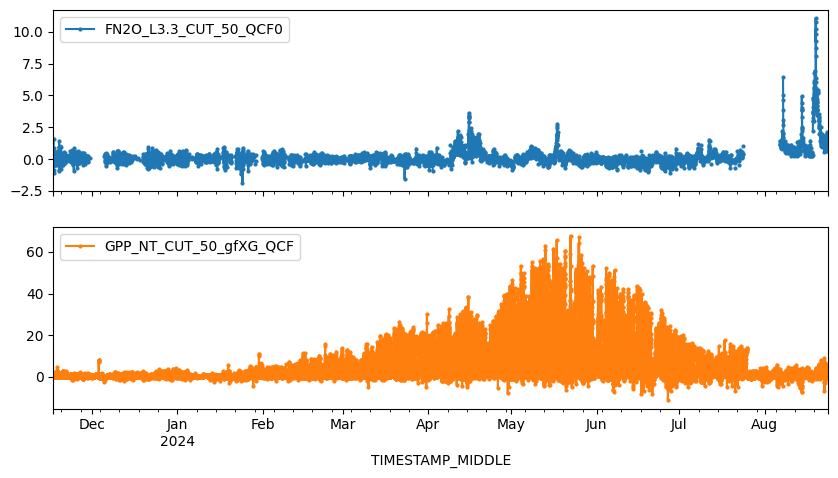

In [175]:
fluxes = load_parquet(filepath=r"../90_FINAL_MERGE/90.1_FLUXES_METEO_MGMT.parquet")
# select relevant columns
cols = ['FN2O_L3.3_CUT_50_QCF0', 'GPP_NT_CUT_50_gfXG_QCF', 'parcel', 'parcel_certainty']
fluxes = fluxes[start_date:end_date][cols].copy()

# plots
indat = fluxes.drop(columns=['parcel', 'parcel_certainty'])
indat.plot(kind='line', subplots=True, layout=(3,1), figsize=(10,8), marker='o', markersize=2);

# show data
fluxes

## METEO

Bulk density data used for WFPS calculation was measured on May 2025.
See file CH-TAN_20250520_soil_bulk_density.xlsx

Loaded .parquet file ../10_METEO/13.1_CH-TAN_meteo_gapfilled.parquet (0.068 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


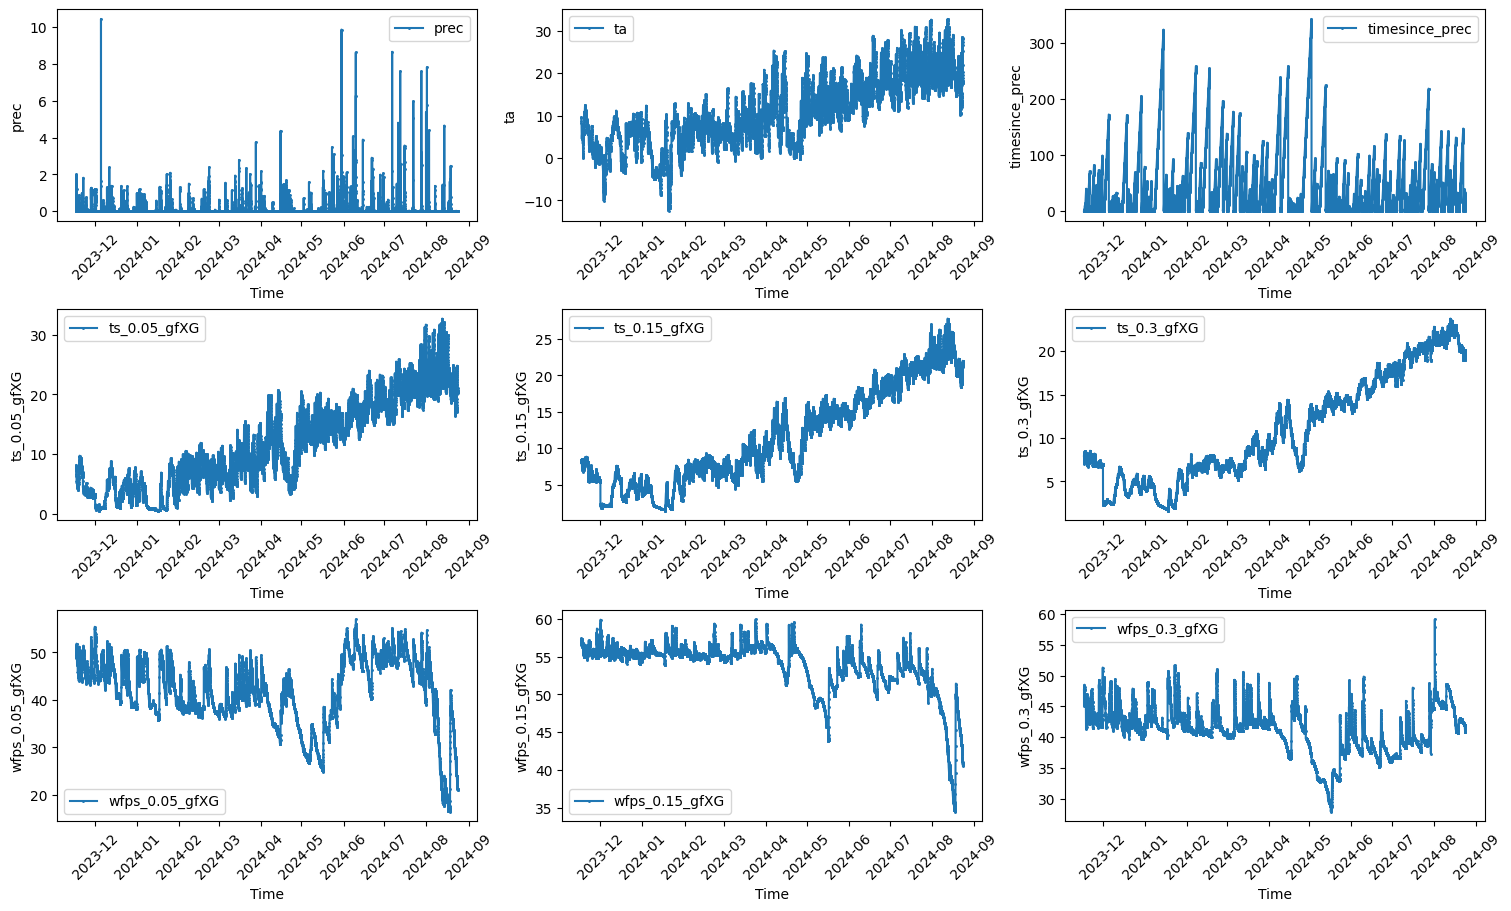

,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG
TIMESTAMP_MIDDLE,,,,,,,,,
2023-11-17 00:15:00,0.4,9.566667,0,7.709492,8.325279,7.916219,49.502770,56.892382,47.683352
2023-11-17 00:45:00,0.0,9.366667,1,7.761147,8.289317,8.027843,49.551355,56.627501,47.442247
2023-11-17 01:15:00,1.3,8.766667,0,7.761220,8.320014,7.992190,50.301234,56.998115,45.149837
2023-11-17 01:45:00,0.0,8.266667,1,7.857418,8.122566,7.730629,51.047444,57.447161,47.225054
2023-11-17 02:15:00,0.0,7.933333,2,8.173503,7.878799,7.674198,50.663760,57.024333,46.870352
...,...,...,...,...,...,...,...,...,...
2024-08-23 21:45:00,0.0,18.230000,29,21.014073,21.597037,20.125925,21.228963,40.716937,40.936844
2024-08-23 22:15:00,0.0,18.056667,30,20.765184,21.467037,20.129259,21.180444,40.674886,40.953472
2024-08-23 22:45:00,0.0,17.716667,31,20.557037,21.365185,20.128518,21.149915,40.648349,40.979679


In [176]:
meteo = load_parquet(filepath=r"../10_METEO/13.1_CH-TAN_meteo_gapfilled.parquet")
meteo = meteo[start_date:end_date].copy()

cols =['prec',
       'ta',
       'timesince_prec', 
       'ts_0.05_gfXG',
       'ts_0.15_gfXG', 
       'ts_0.3_gfXG',
       'swc_0.05_gfXG',
       'swc_0.15_gfXG',
       'swc_0.3_gfXG'
       ]

meteo = meteo[cols]

# Calculate WFPS from SWC using formula with bulk density and particle density
bulk_density = {
    '0.05': 1.1, 
    '0.15': 1.1, 
    '0.3': 1.2, 
}

# Standard particle density since it was not measured
particle_density = 2.65

# Iterate over SWC columns and compute WFPS
swc_cols = [col for col in meteo if col.startswith('swc_')]
for col in swc_cols:
    new_name = col.replace('swc', 'wfps')
    for depth, bd in bulk_density.items():
        if depth in col:
            # calculate wfps for current depth
            wfps = meteo[col] / (1 - (bd / particle_density)) # no need to multiply by 100 because swc is in percent
            meteo[new_name] = wfps
            break

# Now we can remove all the swc columns from which we calculated wfps
meteo.drop(columns=swc_cols, inplace=True)

# plots
plot_data_grid(meteo, ncols=3)

# show data
meteo

## MANAGEMENT

Loaded .parquet file ../20_MANAGEMENT/21.1_mgmt_full_timestamp.parquet (0.118 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


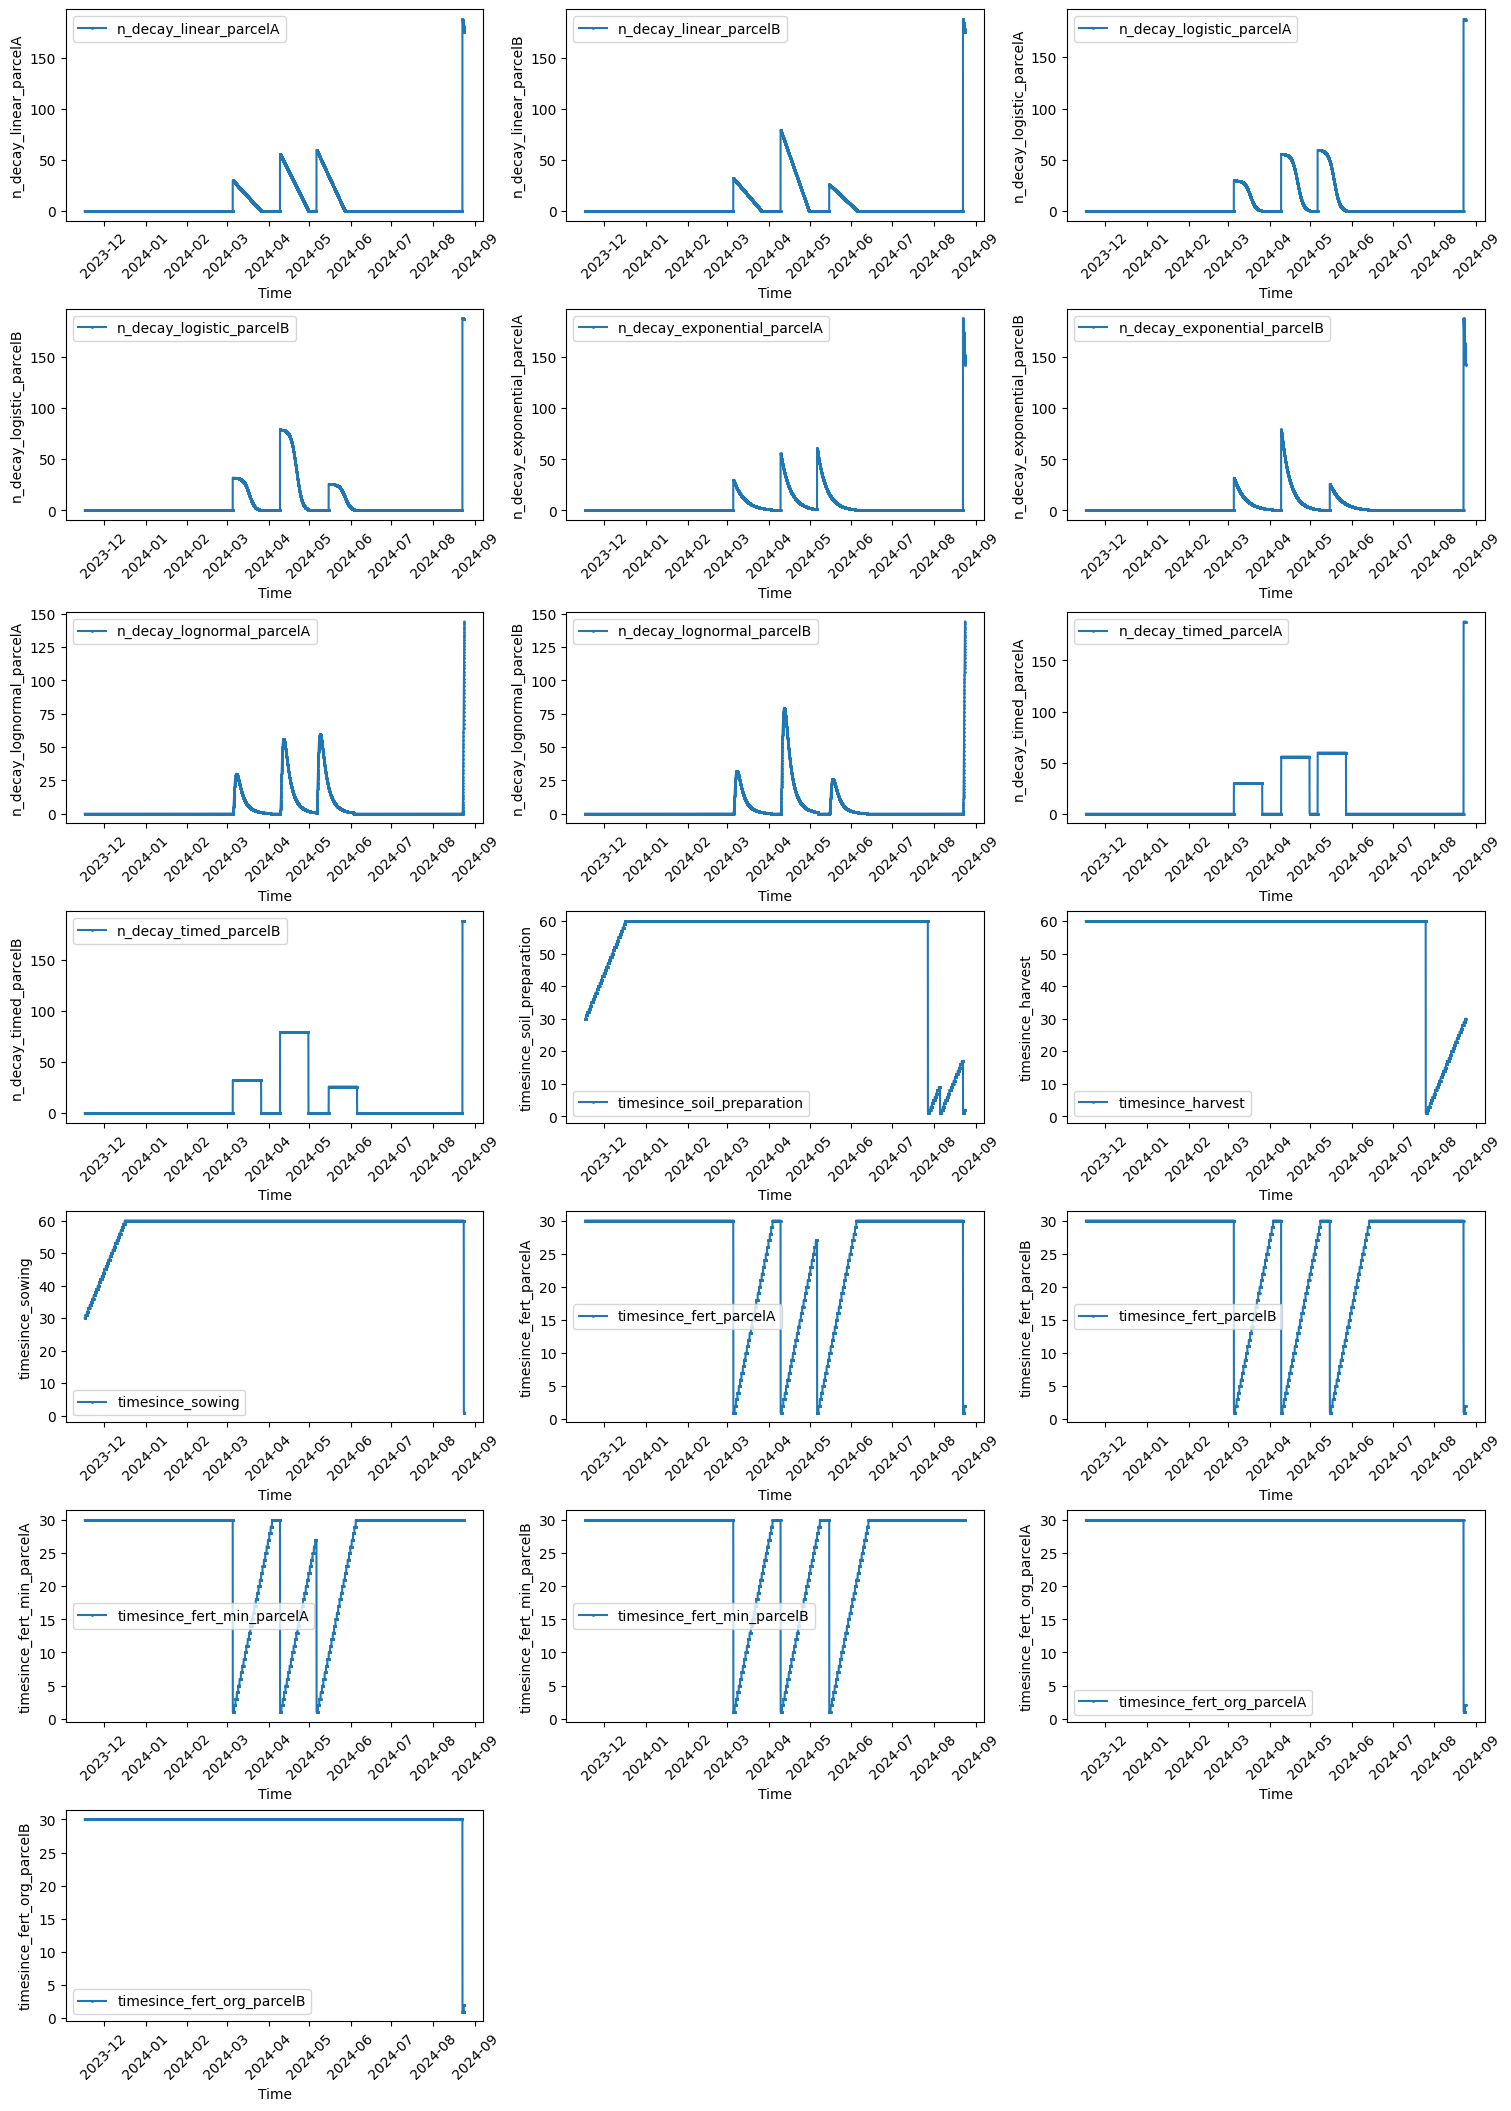

,n_decay_linear_parcelA,n_decay_linear_parcelB,n_decay_logistic_parcelA,n_decay_logistic_parcelB,n_decay_exponential_parcelA,n_decay_exponential_parcelB,n_decay_lognormal_parcelA,n_decay_lognormal_parcelB,n_decay_timed_parcelA,n_decay_timed_parcelB,timesince_soil_preparation,timesince_harvest,timesince_sowing,timesince_fert_parcelA,timesince_fert_parcelB,timesince_fert_min_parcelA,timesince_fert_min_parcelB,timesince_fert_org_parcelA,timesince_fert_org_parcelB
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,
2023-11-17 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,30,60,30,30,30,30,30,30,30
2023-11-17 00:45:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,30,60,30,30,30,30,30,30,30
2023-11-17 01:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,30,60,30,30,30,30,30,30,30
2023-11-17 01:45:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,30,60,30,30,30,30,30,30,30
2023-11-17 02:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,30,60,30,30,30,30,30,30,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-23 21:45:00,175.503968,175.503968,186.849378,186.849378,144.806606,144.806606,136.448807,136.448807,188.0,188.0,2,30,1,2,2,30,30,2,2
2024-08-23 22:15:00,175.317460,175.317460,186.837885,186.837885,144.243513,144.243513,138.433911,138.433911,188.0,188.0,2,30,1,2,2,30,30,2,2
2024-08-23 22:45:00,175.130952,175.130952,186.826279,186.826279,143.682610,143.682610,140.372959,140.372959,188.0,188.0,2,30,1,2,2,30,30,2,2


In [177]:
management = load_parquet(filepath=r"../20_MANAGEMENT/21.1_mgmt_full_timestamp.parquet")
management = management[start_date:end_date].copy()

# select subset of columns
prefix = ('n_decay', 'timesince', 'timed')
cols = [c for c in management.columns if c.startswith(prefix)]
management = management[cols]

# plots
plot_data_grid(management, ncols=3)

# show data
management

## CANOPY

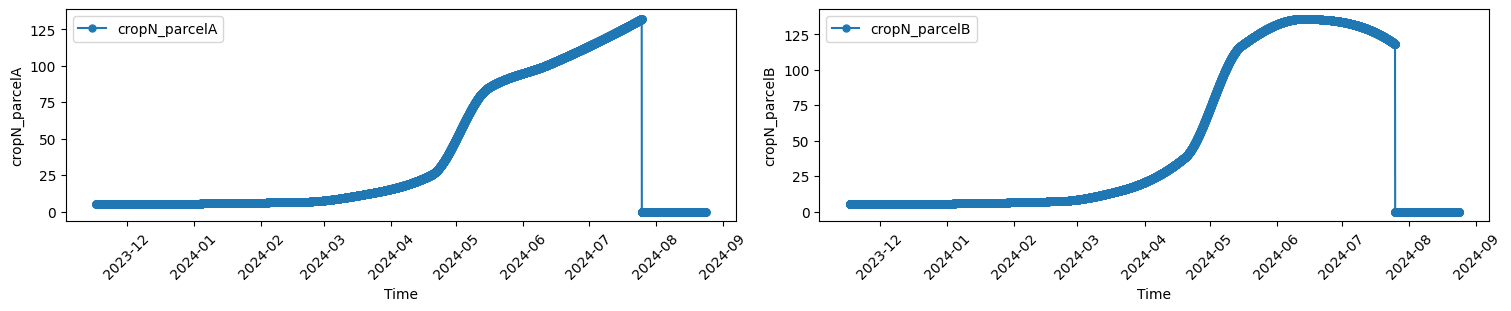

,cropN_parcelA,cropN_parcelB
TIMESTAMP_MIDDLE,,
2023-11-17 00:15:00,5.027077,5.035299
2023-11-17 00:45:00,5.027151,5.035396
2023-11-17 01:15:00,5.027226,5.035493
2023-11-17 01:45:00,5.027300,5.035590
2023-11-17 02:15:00,5.027375,5.035688
...,...,...
2024-08-23 21:45:00,0.002648,0.001622
2024-08-23 22:15:00,0.002933,0.001797
2024-08-23 22:45:00,0.003234,0.001981


In [178]:
vars_ = ["cropN"]
canopy = None
for var in vars_:
    df = pd.read_csv(f"../../data/CANOPY/02-{var}_model.csv")
    canopy = df if canopy is None else canopy.merge(df, on='TIMESTAMP_MIDDLE', how="outer")

canopy = canopy.sort_values('TIMESTAMP_MIDDLE')
canopy['TIMESTAMP_MIDDLE'] = pd.to_datetime(canopy['TIMESTAMP_MIDDLE'])
canopy.set_index('TIMESTAMP_MIDDLE', inplace=True)
canopy = canopy[start_date:end_date].copy()
# select only parcel columns
canopy = canopy[[c for c in canopy if 'parcel' in c]].copy()

# plots
plot_data_grid(canopy, ncols=2)

# show data
canopy

# MERGE DATA

## MERGE

In [179]:
df = pd.concat([fluxes, meteo, management, canopy], axis=1)

## SANITIZE TIMESTAMP

In [180]:
# Remove duplicates, keep first
locs_duplicates = df.index.duplicated(keep='first')
print(f"Found duplicates in index: {locs_duplicates.sum()}")
df = df[~locs_duplicates]

# Remove NaTs
locs_nats = df.index.isnull()
print(f"Found NaTs in index: {locs_nats.sum()}")
df = df[~locs_nats]

# Sort timestamp index
df = df.sort_index(ascending=True)

df

Found duplicates in index: 0
Found NaTs in index: 0


,FN2O_L3.3_CUT_50_QCF0,GPP_NT_CUT_50_gfXG_QCF,parcel,parcel_certainty,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,n_decay_linear_parcelA,n_decay_linear_parcelB,...,n_decay_lognormal_parcelA,n_decay_lognormal_parcelB,n_decay_timed_parcelA,n_decay_timed_parcelB,timesince_soil_preparation,timesince_harvest,timesince_sowing,timesince_fert_parcelA,timesince_fert_parcelB,timesince_fert_min_parcelA,timesince_fert_min_parcelB,timesince_fert_org_parcelA,timesince_fert_org_parcelB,cropN_parcelA,cropN_parcelB
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17 00:15:00,-0.856583,0.127180,B,certain,0.4,9.566667,0,7.709492,8.325279,7.916219,49.502770,56.892382,47.683352,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,30,60,30,30,30,30,30,30,30,5.027077,5.035299
2023-11-17 00:45:00,0.475557,0.051548,B,certain,0.0,9.366667,1,7.761147,8.289317,8.027843,49.551355,56.627501,47.442247,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,30,60,30,30,30,30,30,30,30,5.027151,5.035396
2023-11-17 01:15:00,NaN,-0.167277,B,certain,1.3,8.766667,0,7.761220,8.320014,7.992190,50.301234,56.998115,45.149837,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,30,60,30,30,30,30,30,30,30,5.027226,5.035493
2023-11-17 01:45:00,0.335770,0.066962,B,certain,0.0,8.266667,1,7.857418,8.122566,7.730629,51.047444,57.447161,47.225054,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,30,60,30,30,30,30,30,30,30,5.027300,5.035590
2023-11-17 02:15:00,0.420791,0.104486,B,certain,0.0,7.933333,2,8.173503,7.878799,7.674198,50.663760,57.024333,46.870352,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,30,60,30,30,30,30,30,30,30,5.027375,5.035688
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-23 21:45:00,NaN,0.407134,B,certain,0.0,18.230000,29,21.014073,21.597037,20.125925,21.228963,40.716937,40.936844,175.503968,175.503968,...,136.448807,136.448807,188.0,188.0,2,30,1,2,2,30,30,2,2,0.002648,0.001622
2024-08-23 22:15:00,1.736854,1.769005,B,certain,0.0,18.056667,30,20.765184,21.467037,20.129259,21.180444,40.674886,40.953472,175.317460,175.317460,...,138.433911,138.433911,188.0,188.0,2,30,1,2,2,30,30,2,2,0.002933,0.001797
2024-08-23 22:45:00,NaN,0.403647,B,certain,0.0,17.716667,31,20.557037,21.365185,20.128518,21.149915,40.648349,40.979679,175.130952,175.130952,...,140.372959,140.372959,188.0,188.0,2,30,1,2,2,30,30,2,2,0.003234,0.001981


In [181]:
[c for c in df.columns if 'parcel' in c]

['parcel',
 'parcel_certainty',
 'n_decay_linear_parcelA',
 'n_decay_linear_parcelB',
 'n_decay_logistic_parcelA',
 'n_decay_logistic_parcelB',
 'n_decay_exponential_parcelA',
 'n_decay_exponential_parcelB',
 'n_decay_lognormal_parcelA',
 'n_decay_lognormal_parcelB',
 'n_decay_timed_parcelA',
 'n_decay_timed_parcelB',
 'timesince_fert_parcelA',
 'timesince_fert_parcelB',
 'timesince_fert_min_parcelA',
 'timesince_fert_min_parcelB',
 'timesince_fert_org_parcelA',
 'timesince_fert_org_parcelB',
 'cropN_parcelA',
 'cropN_parcelB']

# RESAMPLE

In [182]:
frequency = "8h"  # or "8h"
flux_col = "FN2O_L3.3_CUT_50_QCF0"

metadata_cols = ["parcel", "parcel_certainty"]

# If you truly have parcel-specific columns like "..._parcelA" / "..._parcelB"
parcel_cols_A = [c for c in df.columns if "_parcelA" in c]
parcel_cols_B = [c for c in df.columns if "_parcelB" in c]
parcel_specific_cols = parcel_cols_A + parcel_cols_B

# Shared drivers: aggregate from FULL dataset (do not filter by parcel)
shared_cols = [
    c for c in df.columns
    if c not in metadata_cols + parcel_specific_cols + [flux_col]
]
agg_map_shared = {c: ("sum" if c.startswith("prec") or c.startswith("GPP") else "max" if c.startswith('timesince') else "mean") for c in shared_cols}
shared_resampled = df[shared_cols].resample(frequency).agg(agg_map_shared)

# Flux: aggregate PER PARCEL using only confident assignments
mask_A = (df["parcel"] == "A") & (df["parcel_certainty"] == "certain")
mask_B = (df["parcel"] == "B") & (df["parcel_certainty"] == "certain")
flux_A = df.loc[mask_A, flux_col].resample(frequency).mean().rename(flux_col)
flux_B = df.loc[mask_B, flux_col].resample(frequency).mean().rename(flux_col)

# Parcel-specific drivers
agg_map_A = {c: ("max" if c.startswith("timesince") else "mean") for c in parcel_cols_A}
agg_map_B = {c: ("max" if c.startswith("timesince") else "mean") for c in parcel_cols_B}

parcelA_specific_resampled = (
    df[parcel_cols_A].resample(frequency).agg(agg_map_A) if parcel_cols_A else pd.DataFrame(index=shared_resampled.index)
)
parcelB_specific_resampled = (
    df[parcel_cols_B].resample(frequency).agg(agg_map_B) if parcel_cols_B else pd.DataFrame(index=shared_resampled.index)
)

# Build two separate dataframes for each parcel
# A
df_A = pd.concat([shared_resampled, parcelA_specific_resampled, flux_A.rename(flux_col)], axis=1)
df_A["trt"] = 0
# B
df_B = pd.concat([shared_resampled, parcelB_specific_resampled, flux_B.rename(flux_col)], axis=1)
df_B["trt"] = 1

# Get rid of the suffix for parcel from column names
df_A.columns = df_A.columns.str.replace('_parcelA$', '', regex=True)
df_B.columns = df_B.columns.str.replace('_parcelB$', '', regex=True)

# Check the aggregated datasets
print("Shared rows:", shared_resampled.shape[0])
print("\nParcel A dataframe:\n rows:", df_A.shape[0], "\nnon-NA flux:", df_A[flux_col].notna().sum())
print("\nParcel B dataframe:\n rows:", df_B.shape[0], "\nnon-NA flux:", df_B[flux_col].notna().sum())

# Show the dataframes
display(df_A)
display(df_B)

Shared rows: 843

Parcel A dataframe:
 rows: 843 
non-NA flux: 291

Parcel B dataframe:
 rows: 843 
non-NA flux: 540


,GPP_NT_CUT_50_gfXG_QCF,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,cropN,FN2O_L3.3_CUT_50_QCF0,trt
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17 00:00:00,2.969070,7.700,6.829167,3,7.236310,8.197311,7.576144,49.895811,56.984464,47.046478,30,60,30,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,5.027638,0.197910,0
2023-11-17 08:00:00,20.423914,1.300,5.720833,9,5.341264,7.955000,8.046294,50.004324,56.646529,47.119731,31,60,31,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,5.028851,NaN,0
2023-11-17 16:00:00,-1.671137,0.800,5.285417,10,5.006101,7.607891,8.192588,48.380839,56.596784,46.591793,31,60,31,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,5.030091,NaN,0
2023-11-18 00:00:00,0.852672,0.000,2.397917,25,4.821761,7.398998,7.798999,46.682229,56.151947,45.336984,31,60,31,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,5.031358,NaN,0
2023-11-18 08:00:00,30.765112,0.100,4.531250,40,4.716984,7.135065,7.597872,45.904342,55.583304,43.229842,32,60,32,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,5.032652,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 08:00:00,25.665771,0.017,19.833333,15,20.300300,19.204606,19.083796,27.428279,44.057218,42.316311,17,29,60,93.673611,93.694163,92.730558,0.055139,94.0,30,30,30,0.000000,1.268375,0
2024-08-22 16:00:00,1.923900,0.000,19.433333,31,21.991296,21.363889,19.789259,25.202767,43.408123,42.060880,1,29,60,185.109127,187.310080,177.011151,8.352075,188.0,1,30,1,0.000000,NaN,0
2024-08-23 00:00:00,0.985246,0.085,13.631875,39,17.947324,19.732477,19.599745,24.124449,43.127889,42.017543,1,29,60,182.125000,187.190888,166.313429,42.980959,188.0,1,30,1,0.000000,NaN,0


,GPP_NT_CUT_50_gfXG_QCF,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,cropN,FN2O_L3.3_CUT_50_QCF0,trt
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17 00:00:00,2.969070,7.700,6.829167,3,7.236310,8.197311,7.576144,49.895811,56.984464,47.046478,30,60,30,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,5.036031,-0.163722,1
2023-11-17 08:00:00,20.423914,1.300,5.720833,9,5.341264,7.955000,8.046294,50.004324,56.646529,47.119731,31,60,31,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,5.037615,-0.012439,1
2023-11-17 16:00:00,-1.671137,0.800,5.285417,10,5.006101,7.607891,8.192588,48.380839,56.596784,46.591793,31,60,31,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,5.039234,0.121575,1
2023-11-18 00:00:00,0.852672,0.000,2.397917,25,4.821761,7.398998,7.798999,46.682229,56.151947,45.336984,31,60,31,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,5.040889,NaN,1
2023-11-18 08:00:00,30.765112,0.100,4.531250,40,4.716984,7.135065,7.597872,45.904342,55.583304,43.229842,32,60,32,0.000000,0.000000,0.000000,0.000000,0.0,30,30,30,5.042579,0.292255,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 08:00:00,25.665771,0.017,19.833333,15,20.300300,19.204606,19.083796,27.428279,44.057218,42.316311,17,29,60,93.673611,93.694163,92.730558,0.055139,94.0,30,30,30,0.000000,1.532408,1
2024-08-22 16:00:00,1.923900,0.000,19.433333,31,21.991296,21.363889,19.789259,25.202767,43.408123,42.060880,1,29,60,185.109127,187.310080,177.011151,8.352075,188.0,1,30,1,0.000000,1.664724,1
2024-08-23 00:00:00,0.985246,0.085,13.631875,39,17.947324,19.732477,19.599745,24.124449,43.127889,42.017543,1,29,60,182.125000,187.190888,166.313429,42.980959,188.0,1,30,1,0.000000,NaN,1


# LAGGED VARIANTS

Variables for which lagged variants will be calculated:

In [183]:
# Define columns of interest
_list_lag_vars = [
    'prec',
    'ta',
    'ts_0.05_gfXG', 'ts_0.15_gfXG', 'ts_0.3_gfXG', 
    'wfps_0.05_gfXG', 'wfps_0.15_gfXG', 'wfps_0.3_gfXG',
    'GPP_NT_CUT_50_gfXG_QCF'
]

_list_lag_vars = [c for c in df.columns if any([c.startswith(v) for v in _list_lag_vars])]

_list_lag_vars

['GPP_NT_CUT_50_gfXG_QCF',
 'prec',
 'ta',
 'ts_0.05_gfXG',
 'ts_0.15_gfXG',
 'ts_0.3_gfXG',
 'wfps_0.05_gfXG',
 'wfps_0.15_gfXG',
 'wfps_0.3_gfXG']

Calculate the lagged variants

,GPP_NT_CUT_50_gfXG_QCF,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,...,ts_0.15_gfXG_lag8h,ts_0.15_gfXG_lag16h,ts_0.15_gfXG_lag24h,ts_0.3_gfXG_lag8h,ts_0.3_gfXG_lag16h,ts_0.3_gfXG_lag24h,wfps_0.05_gfXG_lag8h,wfps_0.05_gfXG_lag16h,wfps_0.05_gfXG_lag24h,wfps_0.15_gfXG_lag8h,wfps_0.15_gfXG_lag16h,wfps_0.15_gfXG_lag24h,wfps_0.3_gfXG_lag8h,wfps_0.3_gfXG_lag16h,wfps_0.3_gfXG_lag24h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17 00:00:00,2.969070,7.700,6.829167,3,7.236310,8.197311,7.576144,49.895811,56.984464,47.046478,30,60,30,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-17 08:00:00,20.423914,1.300,5.720833,9,5.341264,7.955000,8.046294,50.004324,56.646529,47.119731,31,60,31,0.000000,0.000000,...,8.197311,NaN,NaN,7.576144,NaN,NaN,49.895811,NaN,NaN,56.984464,NaN,NaN,47.046478,NaN,NaN
2023-11-17 16:00:00,-1.671137,0.800,5.285417,10,5.006101,7.607891,8.192588,48.380839,56.596784,46.591793,31,60,31,0.000000,0.000000,...,7.955000,8.197311,NaN,8.046294,7.576144,NaN,50.004324,49.895811,NaN,56.646529,56.984464,NaN,47.119731,47.046478,NaN
2023-11-18 00:00:00,0.852672,0.000,2.397917,25,4.821761,7.398998,7.798999,46.682229,56.151947,45.336984,31,60,31,0.000000,0.000000,...,7.607891,7.955000,8.197311,8.192588,8.046294,7.576144,48.380839,50.004324,49.895811,56.596784,56.646529,56.984464,46.591793,47.119731,47.046478
2023-11-18 08:00:00,30.765112,0.100,4.531250,40,4.716984,7.135065,7.597872,45.904342,55.583304,43.229842,32,60,32,0.000000,0.000000,...,7.398998,7.607891,7.955000,7.798999,8.192588,8.046294,46.682229,48.380839,50.004324,56.151947,56.596784,56.646529,45.336984,46.591793,47.119731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 08:00:00,25.665771,0.017,19.833333,15,20.300300,19.204606,19.083796,27.428279,44.057218,42.316311,17,29,60,93.673611,93.694163,...,19.370486,21.195949,20.419259,19.725046,20.217870,19.986018,28.097403,29.307998,31.746818,44.633833,44.878902,45.525360,42.448507,42.521917,42.701680
2024-08-22 16:00:00,1.923900,0.000,19.433333,31,21.991296,21.363889,19.789259,25.202767,43.408123,42.060880,1,29,60,185.109127,187.310080,...,19.204606,19.370486,21.195949,19.083796,19.725046,20.217870,27.428279,28.097403,29.307998,44.057218,44.633833,44.878902,42.316311,42.448507,42.521917
2024-08-23 00:00:00,0.985246,0.085,13.631875,39,17.947324,19.732477,19.599745,24.124449,43.127889,42.017543,1,29,60,182.125000,187.190888,...,21.363889,19.204606,19.370486,19.789259,19.083796,19.725046,25.202767,27.428279,28.097403,43.408123,44.057218,44.633833,42.060880,42.316311,42.448507


,GPP_NT_CUT_50_gfXG_QCF,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,...,ts_0.15_gfXG_lag8h,ts_0.15_gfXG_lag16h,ts_0.15_gfXG_lag24h,ts_0.3_gfXG_lag8h,ts_0.3_gfXG_lag16h,ts_0.3_gfXG_lag24h,wfps_0.05_gfXG_lag8h,wfps_0.05_gfXG_lag16h,wfps_0.05_gfXG_lag24h,wfps_0.15_gfXG_lag8h,wfps_0.15_gfXG_lag16h,wfps_0.15_gfXG_lag24h,wfps_0.3_gfXG_lag8h,wfps_0.3_gfXG_lag16h,wfps_0.3_gfXG_lag24h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17 00:00:00,2.969070,7.700,6.829167,3,7.236310,8.197311,7.576144,49.895811,56.984464,47.046478,30,60,30,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-17 08:00:00,20.423914,1.300,5.720833,9,5.341264,7.955000,8.046294,50.004324,56.646529,47.119731,31,60,31,0.000000,0.000000,...,8.197311,NaN,NaN,7.576144,NaN,NaN,49.895811,NaN,NaN,56.984464,NaN,NaN,47.046478,NaN,NaN
2023-11-17 16:00:00,-1.671137,0.800,5.285417,10,5.006101,7.607891,8.192588,48.380839,56.596784,46.591793,31,60,31,0.000000,0.000000,...,7.955000,8.197311,NaN,8.046294,7.576144,NaN,50.004324,49.895811,NaN,56.646529,56.984464,NaN,47.119731,47.046478,NaN
2023-11-18 00:00:00,0.852672,0.000,2.397917,25,4.821761,7.398998,7.798999,46.682229,56.151947,45.336984,31,60,31,0.000000,0.000000,...,7.607891,7.955000,8.197311,8.192588,8.046294,7.576144,48.380839,50.004324,49.895811,56.596784,56.646529,56.984464,46.591793,47.119731,47.046478
2023-11-18 08:00:00,30.765112,0.100,4.531250,40,4.716984,7.135065,7.597872,45.904342,55.583304,43.229842,32,60,32,0.000000,0.000000,...,7.398998,7.607891,7.955000,7.798999,8.192588,8.046294,46.682229,48.380839,50.004324,56.151947,56.596784,56.646529,45.336984,46.591793,47.119731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 08:00:00,25.665771,0.017,19.833333,15,20.300300,19.204606,19.083796,27.428279,44.057218,42.316311,17,29,60,93.673611,93.694163,...,19.370486,21.195949,20.419259,19.725046,20.217870,19.986018,28.097403,29.307998,31.746818,44.633833,44.878902,45.525360,42.448507,42.521917,42.701680
2024-08-22 16:00:00,1.923900,0.000,19.433333,31,21.991296,21.363889,19.789259,25.202767,43.408123,42.060880,1,29,60,185.109127,187.310080,...,19.204606,19.370486,21.195949,19.083796,19.725046,20.217870,27.428279,28.097403,29.307998,44.057218,44.633833,44.878902,42.316311,42.448507,42.521917
2024-08-23 00:00:00,0.985246,0.085,13.631875,39,17.947324,19.732477,19.599745,24.124449,43.127889,42.017543,1,29,60,182.125000,187.190888,...,21.363889,19.204606,19.370486,19.789259,19.083796,19.725046,25.202767,27.428279,28.097403,43.408123,44.057218,44.633833,42.060880,42.316311,42.448507


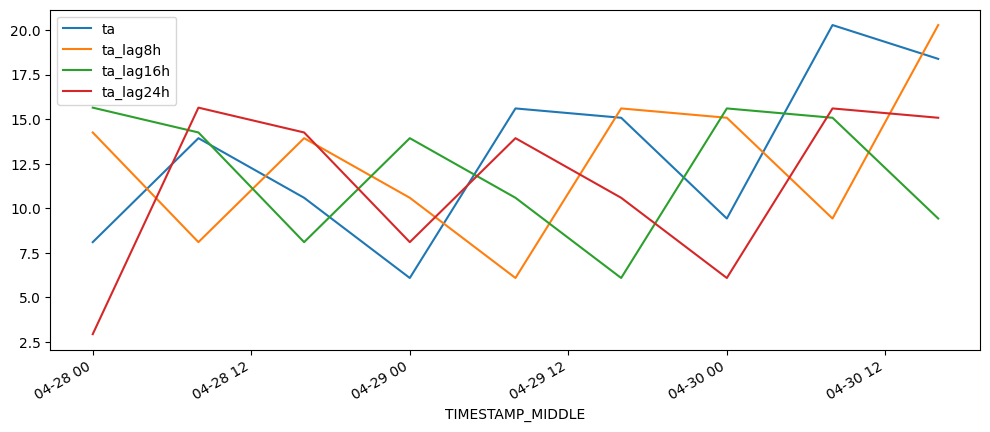

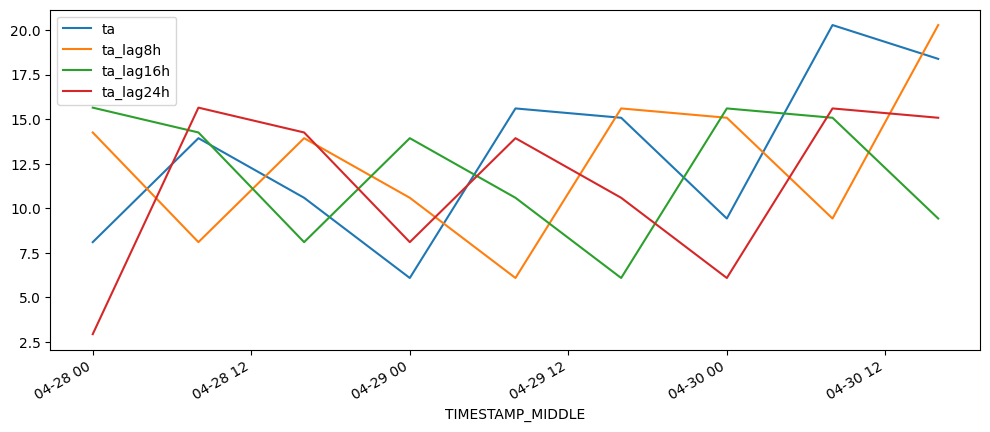

In [184]:
# Define time intervals
intervals = [8, 16, 24] # in hours

# Time resolution of the dataframe
time_res = float(frequency.replace("h", ""))

# Create lagged variants
for df in [df_A, df_B]:
    for v in _list_lag_vars:
        for lag in intervals:
            lag_adjusted = int(lag/time_res)
            if lag_adjusted > 0:
                var_lag = f'{v}_lag{lag}h'
                df[var_lag] = df[v].shift(lag_adjusted)

    # Plot the lag vars for TA
    indat = df[[c for c in df.columns if c.startswith('ta')]]
    indat = indat.loc['2024-04-28':'2024-04-30']
    indat.plot(x_compat=True, figsize=(12, 5));

display(df_A)
display(df_B)

# ROLLING VARIANTS

Variables for which rolling variants will be calculated:

In [185]:
# Define columns of interest
_list_rolling_vars = [c for c in df_A.columns if c.startswith(tuple(_list_lag_vars))]
_list_rolling_vars

['GPP_NT_CUT_50_gfXG_QCF',
 'prec',
 'ta',
 'ts_0.05_gfXG',
 'ts_0.15_gfXG',
 'ts_0.3_gfXG',
 'wfps_0.05_gfXG',
 'wfps_0.15_gfXG',
 'wfps_0.3_gfXG',
 'GPP_NT_CUT_50_gfXG_QCF_lag8h',
 'GPP_NT_CUT_50_gfXG_QCF_lag16h',
 'GPP_NT_CUT_50_gfXG_QCF_lag24h',
 'prec_lag8h',
 'prec_lag16h',
 'prec_lag24h',
 'ta_lag8h',
 'ta_lag16h',
 'ta_lag24h',
 'ts_0.05_gfXG_lag8h',
 'ts_0.05_gfXG_lag16h',
 'ts_0.05_gfXG_lag24h',
 'ts_0.15_gfXG_lag8h',
 'ts_0.15_gfXG_lag16h',
 'ts_0.15_gfXG_lag24h',
 'ts_0.3_gfXG_lag8h',
 'ts_0.3_gfXG_lag16h',
 'ts_0.3_gfXG_lag24h',
 'wfps_0.05_gfXG_lag8h',
 'wfps_0.05_gfXG_lag16h',
 'wfps_0.05_gfXG_lag24h',
 'wfps_0.15_gfXG_lag8h',
 'wfps_0.15_gfXG_lag16h',
 'wfps_0.15_gfXG_lag24h',
 'wfps_0.3_gfXG_lag8h',
 'wfps_0.3_gfXG_lag16h',
 'wfps_0.3_gfXG_lag24h']

Calculate the rolling variants

,GPP_NT_CUT_50_gfXG_QCF,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,...,ts_0.15_gfXG_lag16h,ts_0.15_gfXG_lag24h,ts_0.3_gfXG_lag8h,ts_0.3_gfXG_lag16h,ts_0.3_gfXG_lag24h,wfps_0.05_gfXG_lag8h,wfps_0.05_gfXG_lag16h,wfps_0.05_gfXG_lag24h,wfps_0.15_gfXG_lag8h,wfps_0.15_gfXG_lag16h,wfps_0.15_gfXG_lag24h,wfps_0.3_gfXG_lag8h,wfps_0.3_gfXG_lag16h,wfps_0.3_gfXG_lag24h,GPP_NT_CUT_50_gfXG_QCF_roll8hsum
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17 00:00:00,2.969070,7.700,6.829167,3,7.236310,8.197311,7.576144,49.895811,56.984464,47.046478,30,60,30,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.969070
2023-11-17 08:00:00,20.423914,1.300,5.720833,9,5.341264,7.955000,8.046294,50.004324,56.646529,47.119731,31,60,31,0.000000,0.000000,...,NaN,NaN,7.576144,NaN,NaN,49.895811,NaN,NaN,56.984464,NaN,NaN,47.046478,NaN,NaN,20.423914
2023-11-17 16:00:00,-1.671137,0.800,5.285417,10,5.006101,7.607891,8.192588,48.380839,56.596784,46.591793,31,60,31,0.000000,0.000000,...,8.197311,NaN,8.046294,7.576144,NaN,50.004324,49.895811,NaN,56.646529,56.984464,NaN,47.119731,47.046478,NaN,-1.671137
2023-11-18 00:00:00,0.852672,0.000,2.397917,25,4.821761,7.398998,7.798999,46.682229,56.151947,45.336984,31,60,31,0.000000,0.000000,...,7.955000,8.197311,8.192588,8.046294,7.576144,48.380839,50.004324,49.895811,56.596784,56.646529,56.984464,46.591793,47.119731,47.046478,0.852672
2023-11-18 08:00:00,30.765112,0.100,4.531250,40,4.716984,7.135065,7.597872,45.904342,55.583304,43.229842,32,60,32,0.000000,0.000000,...,7.607891,7.955000,7.798999,8.192588,8.046294,46.682229,48.380839,50.004324,56.151947,56.596784,56.646529,45.336984,46.591793,47.119731,30.765112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 08:00:00,25.665771,0.017,19.833333,15,20.300300,19.204606,19.083796,27.428279,44.057218,42.316311,17,29,60,93.673611,93.694163,...,21.195949,20.419259,19.725046,20.217870,19.986018,28.097403,29.307998,31.746818,44.633833,44.878902,45.525360,42.448507,42.521917,42.701680,25.665771
2024-08-22 16:00:00,1.923900,0.000,19.433333,31,21.991296,21.363889,19.789259,25.202767,43.408123,42.060880,1,29,60,185.109127,187.310080,...,19.370486,21.195949,19.083796,19.725046,20.217870,27.428279,28.097403,29.307998,44.057218,44.633833,44.878902,42.316311,42.448507,42.521917,1.923900
2024-08-23 00:00:00,0.985246,0.085,13.631875,39,17.947324,19.732477,19.599745,24.124449,43.127889,42.017543,1,29,60,182.125000,187.190888,...,19.204606,19.370486,19.789259,19.083796,19.725046,25.202767,27.428279,28.097403,43.408123,44.057218,44.633833,42.060880,42.316311,42.448507,0.985246


,GPP_NT_CUT_50_gfXG_QCF,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,...,ts_0.15_gfXG_lag16h,ts_0.15_gfXG_lag24h,ts_0.3_gfXG_lag8h,ts_0.3_gfXG_lag16h,ts_0.3_gfXG_lag24h,wfps_0.05_gfXG_lag8h,wfps_0.05_gfXG_lag16h,wfps_0.05_gfXG_lag24h,wfps_0.15_gfXG_lag8h,wfps_0.15_gfXG_lag16h,wfps_0.15_gfXG_lag24h,wfps_0.3_gfXG_lag8h,wfps_0.3_gfXG_lag16h,wfps_0.3_gfXG_lag24h,GPP_NT_CUT_50_gfXG_QCF_roll8hsum
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17 00:00:00,2.969070,7.700,6.829167,3,7.236310,8.197311,7.576144,49.895811,56.984464,47.046478,30,60,30,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.969070
2023-11-17 08:00:00,20.423914,1.300,5.720833,9,5.341264,7.955000,8.046294,50.004324,56.646529,47.119731,31,60,31,0.000000,0.000000,...,NaN,NaN,7.576144,NaN,NaN,49.895811,NaN,NaN,56.984464,NaN,NaN,47.046478,NaN,NaN,20.423914
2023-11-17 16:00:00,-1.671137,0.800,5.285417,10,5.006101,7.607891,8.192588,48.380839,56.596784,46.591793,31,60,31,0.000000,0.000000,...,8.197311,NaN,8.046294,7.576144,NaN,50.004324,49.895811,NaN,56.646529,56.984464,NaN,47.119731,47.046478,NaN,-1.671137
2023-11-18 00:00:00,0.852672,0.000,2.397917,25,4.821761,7.398998,7.798999,46.682229,56.151947,45.336984,31,60,31,0.000000,0.000000,...,7.955000,8.197311,8.192588,8.046294,7.576144,48.380839,50.004324,49.895811,56.596784,56.646529,56.984464,46.591793,47.119731,47.046478,0.852672
2023-11-18 08:00:00,30.765112,0.100,4.531250,40,4.716984,7.135065,7.597872,45.904342,55.583304,43.229842,32,60,32,0.000000,0.000000,...,7.607891,7.955000,7.798999,8.192588,8.046294,46.682229,48.380839,50.004324,56.151947,56.596784,56.646529,45.336984,46.591793,47.119731,30.765112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 08:00:00,25.665771,0.017,19.833333,15,20.300300,19.204606,19.083796,27.428279,44.057218,42.316311,17,29,60,93.673611,93.694163,...,21.195949,20.419259,19.725046,20.217870,19.986018,28.097403,29.307998,31.746818,44.633833,44.878902,45.525360,42.448507,42.521917,42.701680,25.665771
2024-08-22 16:00:00,1.923900,0.000,19.433333,31,21.991296,21.363889,19.789259,25.202767,43.408123,42.060880,1,29,60,185.109127,187.310080,...,19.370486,21.195949,19.083796,19.725046,20.217870,27.428279,28.097403,29.307998,44.057218,44.633833,44.878902,42.316311,42.448507,42.521917,1.923900
2024-08-23 00:00:00,0.985246,0.085,13.631875,39,17.947324,19.732477,19.599745,24.124449,43.127889,42.017543,1,29,60,182.125000,187.190888,...,19.204606,19.370486,19.789259,19.083796,19.725046,25.202767,27.428279,28.097403,43.408123,44.057218,44.633833,42.060880,42.316311,42.448507,0.985246


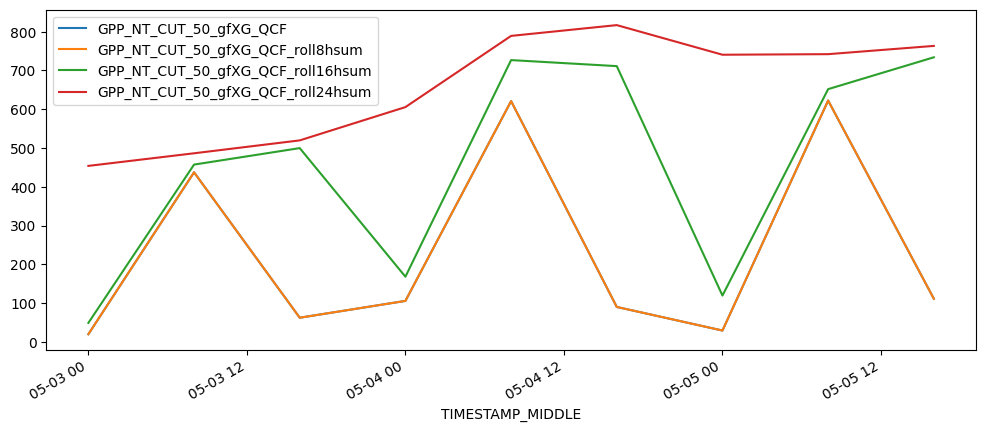

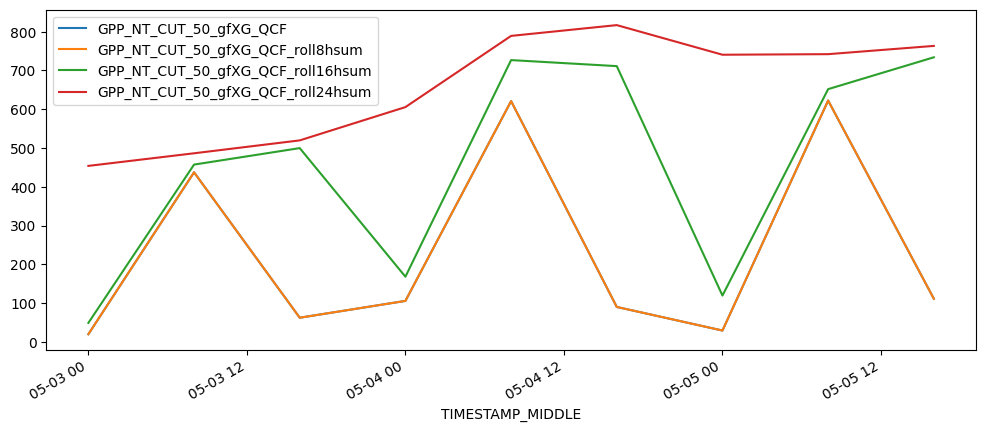

In [186]:
# Define time intervals
#intervals = [24, 48, 72] # in hours

# Time resolution of the dataframe
time_res = float(frequency.replace("h", ""))

# Define the type of aggregations we will apply
aggtypes_default = ['mean']
aggtypes_sum = ['sum'] # for 'prec'


# Create rolling variants
for df in [df_A, df_B]:
    for v in _list_rolling_vars:
        # Determine aggregation type
        aggtypes = aggtypes_sum if v.startswith('prec') or v.startswith('GPP') else aggtypes_default
        for interval in intervals:
            interval_adjusted = int(interval/time_res)
            if interval_adjusted > 0:
                for agg in aggtypes:
                    var_roll = f'{v}_roll{interval}h{agg}'
                    df[var_roll] = df[v].rolling(interval_adjusted, min_periods=1).agg(agg)
                    df = df.copy()

    # Plot the lag vars for GPP
    indat = df[[c for c in df.columns if c.startswith('GPP') and 'lag' not in c]]
    indat = indat.loc['2024-05-03':'2024-05-05']
    indat.plot(x_compat=True, figsize=(12,5));

# Show final dataframes
display(df_A)
display(df_B)

# RATE OF CHANGE

Used for WFPS, TS, and CROP N

In [187]:
# define columns of interest
_list_diff_vars = [col for col in df.columns if ('ts' in col or 'wfps' in col or 'cropN' in col) and ('roll' not in col and 'lag' not in col)]

print(f'We calculate the rate of change for these variables: {_list_diff_vars}')

We calculate the rate of change for these variables: ['ts_0.05_gfXG', 'ts_0.15_gfXG', 'ts_0.3_gfXG', 'wfps_0.05_gfXG', 'wfps_0.15_gfXG', 'wfps_0.3_gfXG', 'cropN']


,GPP_NT_CUT_50_gfXG_QCF,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,...,ts_0.3_gfXG_diff8h,ts_0.3_gfXG_diff16h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff8h,wfps_0.05_gfXG_diff16h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff8h,wfps_0.15_gfXG_diff16h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff8h,wfps_0.3_gfXG_diff16h,wfps_0.3_gfXG_diff24h,cropN_diff8h,cropN_diff16h,cropN_diff24h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17 00:00:00,2.969070,7.700,6.829167,3,7.236310,8.197311,7.576144,49.895811,56.984464,47.046478,30,60,30,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-17 08:00:00,20.423914,1.300,5.720833,9,5.341264,7.955000,8.046294,50.004324,56.646529,47.119731,31,60,31,0.000000,0.000000,...,0.470151,NaN,NaN,0.108514,NaN,NaN,-0.337935,NaN,NaN,0.073253,NaN,NaN,0.001213,NaN,NaN
2023-11-17 16:00:00,-1.671137,0.800,5.285417,10,5.006101,7.607891,8.192588,48.380839,56.596784,46.591793,31,60,31,0.000000,0.000000,...,0.146294,0.616444,NaN,-1.623485,-1.514972,NaN,-0.049745,-0.387679,NaN,-0.527939,-0.454685,NaN,0.001240,0.002453,NaN
2023-11-18 00:00:00,0.852672,0.000,2.397917,25,4.821761,7.398998,7.798999,46.682229,56.151947,45.336984,31,60,31,0.000000,0.000000,...,-0.393589,-0.247295,0.222855,-1.698610,-3.322095,-3.213581,-0.444837,-0.494581,-0.832516,-1.254808,-1.782747,-1.709494,0.001267,0.002507,0.003720
2023-11-18 08:00:00,30.765112,0.100,4.531250,40,4.716984,7.135065,7.597872,45.904342,55.583304,43.229842,32,60,32,0.000000,0.000000,...,-0.201127,-0.594716,-0.448422,-0.777887,-2.476497,-4.099982,-0.568643,-1.013480,-1.063225,-2.107142,-3.361950,-3.889889,0.001294,0.002562,0.003802
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 08:00:00,25.665771,0.017,19.833333,15,20.300300,19.204606,19.083796,27.428279,44.057218,42.316311,17,29,60,93.673611,93.694163,...,-0.641250,-1.134074,-0.902221,-0.669124,-1.879719,-4.318539,-0.576615,-0.821684,-1.468142,-0.132196,-0.205606,-0.385369,0.000000,0.000000,0.000000
2024-08-22 16:00:00,1.923900,0.000,19.433333,31,21.991296,21.363889,19.789259,25.202767,43.408123,42.060880,1,29,60,185.109127,187.310080,...,0.705463,0.064213,-0.428611,-2.225512,-2.894636,-4.105231,-0.649095,-1.225710,-1.470779,-0.255431,-0.387627,-0.461036,0.000000,0.000000,0.000000
2024-08-23 00:00:00,0.985246,0.085,13.631875,39,17.947324,19.732477,19.599745,24.124449,43.127889,42.017543,1,29,60,182.125000,187.190888,...,-0.189514,0.515949,-0.125301,-1.078319,-3.303831,-3.972954,-0.280235,-0.929330,-1.505945,-0.043337,-0.298768,-0.430964,0.000000,0.000000,0.000000


,GPP_NT_CUT_50_gfXG_QCF,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,...,ts_0.3_gfXG_diff8h,ts_0.3_gfXG_diff16h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff8h,wfps_0.05_gfXG_diff16h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff8h,wfps_0.15_gfXG_diff16h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff8h,wfps_0.3_gfXG_diff16h,wfps_0.3_gfXG_diff24h,cropN_diff8h,cropN_diff16h,cropN_diff24h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17 00:00:00,2.969070,7.700,6.829167,3,7.236310,8.197311,7.576144,49.895811,56.984464,47.046478,30,60,30,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-17 08:00:00,20.423914,1.300,5.720833,9,5.341264,7.955000,8.046294,50.004324,56.646529,47.119731,31,60,31,0.000000,0.000000,...,0.470151,NaN,NaN,0.108514,NaN,NaN,-0.337935,NaN,NaN,0.073253,NaN,NaN,0.001584,NaN,NaN
2023-11-17 16:00:00,-1.671137,0.800,5.285417,10,5.006101,7.607891,8.192588,48.380839,56.596784,46.591793,31,60,31,0.000000,0.000000,...,0.146294,0.616444,NaN,-1.623485,-1.514972,NaN,-0.049745,-0.387679,NaN,-0.527939,-0.454685,NaN,0.001619,0.003203,NaN
2023-11-18 00:00:00,0.852672,0.000,2.397917,25,4.821761,7.398998,7.798999,46.682229,56.151947,45.336984,31,60,31,0.000000,0.000000,...,-0.393589,-0.247295,0.222855,-1.698610,-3.322095,-3.213581,-0.444837,-0.494581,-0.832516,-1.254808,-1.782747,-1.709494,0.001655,0.003274,0.004858
2023-11-18 08:00:00,30.765112,0.100,4.531250,40,4.716984,7.135065,7.597872,45.904342,55.583304,43.229842,32,60,32,0.000000,0.000000,...,-0.201127,-0.594716,-0.448422,-0.777887,-2.476497,-4.099982,-0.568643,-1.013480,-1.063225,-2.107142,-3.361950,-3.889889,0.001691,0.003345,0.004965
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 08:00:00,25.665771,0.017,19.833333,15,20.300300,19.204606,19.083796,27.428279,44.057218,42.316311,17,29,60,93.673611,93.694163,...,-0.641250,-1.134074,-0.902221,-0.669124,-1.879719,-4.318539,-0.576615,-0.821684,-1.468142,-0.132196,-0.205606,-0.385369,0.000000,0.000000,0.000000
2024-08-22 16:00:00,1.923900,0.000,19.433333,31,21.991296,21.363889,19.789259,25.202767,43.408123,42.060880,1,29,60,185.109127,187.310080,...,0.705463,0.064213,-0.428611,-2.225512,-2.894636,-4.105231,-0.649095,-1.225710,-1.470779,-0.255431,-0.387627,-0.461036,0.000000,0.000000,0.000000
2024-08-23 00:00:00,0.985246,0.085,13.631875,39,17.947324,19.732477,19.599745,24.124449,43.127889,42.017543,1,29,60,182.125000,187.190888,...,-0.189514,0.515949,-0.125301,-1.078319,-3.303831,-3.972954,-0.280235,-0.929330,-1.505945,-0.043337,-0.298768,-0.430964,0.000000,0.000000,0.000000


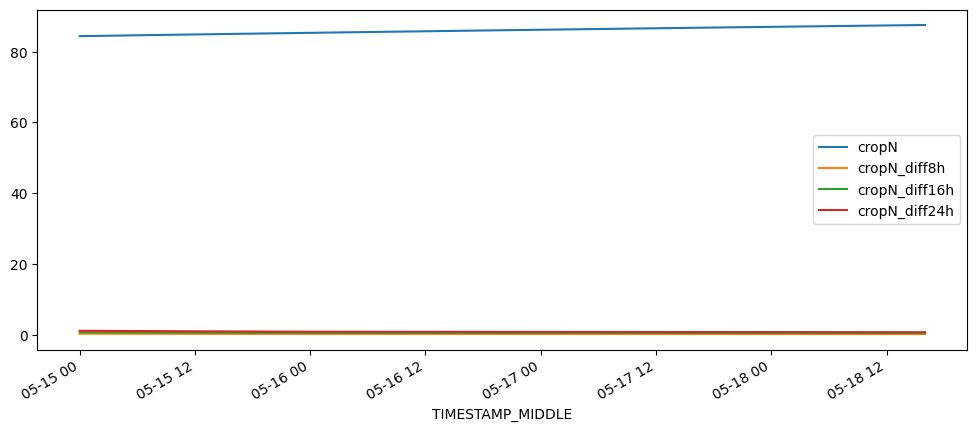

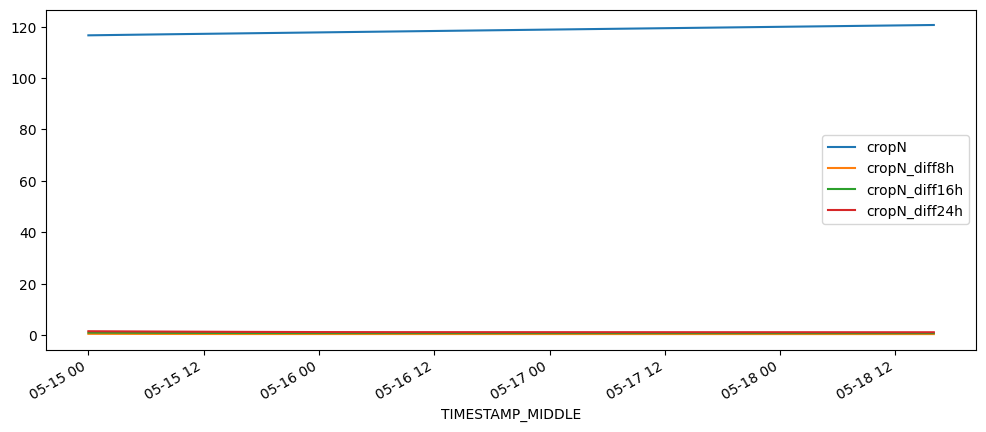

In [188]:
# Define interval of records for the difference calculation
#intervals = [24, 48, 72] # in hours

# Time resolution of the dataframe
time_res = float(frequency.replace("h", ""))

# Create the variants
for df in [df_A, df_B]:
    for v in _list_diff_vars:
        for interval in intervals:
            interval_adjusted = int(interval/time_res)
            if interval_adjusted > 0:
                var_diff = f'{v}_diff{interval}h'
                df[var_diff] = df[v].diff(periods=interval_adjusted)


    # Plot the lag vars for cropN

    indat = df[[c for c in df.columns if c.startswith('cropN') and 'lag' not in c and 'roll' not in c]]
    indat = indat.loc['2024-05-15':'2024-05-18']
    indat.plot(x_compat=True, figsize=(12, 5));

# Show final dataframes
display(df_A)
display(df_B)

# MERGE PARCEL-SPECIFIC DATAFRAMES

In [189]:
# Merge both parcels into a single dataframe
df = pd.concat([df_A, df_B], axis=0).sort_index()
df[['trt', 'FN2O_L3.3_CUT_50_QCF0', 'ta']]

,trt,FN2O_L3.3_CUT_50_QCF0,ta
TIMESTAMP_MIDDLE,,,
2023-11-17 00:00:00,0,0.197910,6.829167
2023-11-17 00:00:00,1,-0.163722,6.829167
2023-11-17 08:00:00,0,NaN,5.720833
2023-11-17 08:00:00,1,-0.012439,5.720833
2023-11-17 16:00:00,0,NaN,5.285417
...,...,...,...
2024-08-23 00:00:00,0,NaN,13.631875
2024-08-23 08:00:00,1,1.373567,25.203125
2024-08-23 08:00:00,0,NaN,25.203125


# EXPORT DATA

## CHECK DATAFRAME

In [190]:
df

,GPP_NT_CUT_50_gfXG_QCF,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,...,ts_0.3_gfXG_diff8h,ts_0.3_gfXG_diff16h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff8h,wfps_0.05_gfXG_diff16h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff8h,wfps_0.15_gfXG_diff16h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff8h,wfps_0.3_gfXG_diff16h,wfps_0.3_gfXG_diff24h,cropN_diff8h,cropN_diff16h,cropN_diff24h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17 00:00:00,2.969070,7.700,6.829167,3,7.236310,8.197311,7.576144,49.895811,56.984464,47.046478,30,60,30,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-17 00:00:00,2.969070,7.700,6.829167,3,7.236310,8.197311,7.576144,49.895811,56.984464,47.046478,30,60,30,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-17 08:00:00,20.423914,1.300,5.720833,9,5.341264,7.955000,8.046294,50.004324,56.646529,47.119731,31,60,31,0.000000,0.000000,...,0.470151,NaN,NaN,0.108514,NaN,NaN,-0.337935,NaN,NaN,0.073253,NaN,NaN,0.001213,NaN,NaN
2023-11-17 08:00:00,20.423914,1.300,5.720833,9,5.341264,7.955000,8.046294,50.004324,56.646529,47.119731,31,60,31,0.000000,0.000000,...,0.470151,NaN,NaN,0.108514,NaN,NaN,-0.337935,NaN,NaN,0.073253,NaN,NaN,0.001584,NaN,NaN
2023-11-17 16:00:00,-1.671137,0.800,5.285417,10,5.006101,7.607891,8.192588,48.380839,56.596784,46.591793,31,60,31,0.000000,0.000000,...,0.146294,0.616444,NaN,-1.623485,-1.514972,NaN,-0.049745,-0.387679,NaN,-0.527939,-0.454685,NaN,0.001240,0.002453,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-23 00:00:00,0.985246,0.085,13.631875,39,17.947324,19.732477,19.599745,24.124449,43.127889,42.017543,1,29,60,182.125000,187.190888,...,-0.189514,0.515949,-0.125301,-1.078319,-3.303831,-3.972954,-0.280235,-0.929330,-1.505945,-0.043337,-0.298768,-0.430964,0.000000,0.000000,0.000000
2024-08-23 08:00:00,20.488471,0.000,25.203125,17,21.265740,19.719097,19.140185,23.266497,42.081508,41.629980,2,30,60,179.140873,187.051208,...,-0.459560,-0.649074,0.056389,-0.857951,-1.936270,-4.161782,-1.046380,-1.326615,-1.975710,-0.387563,-0.430900,-0.686331,0.000039,0.000039,0.000039
2024-08-23 08:00:00,20.488471,0.000,25.203125,17,21.265740,19.719097,19.140185,23.266497,42.081508,41.629980,2,30,60,179.140873,187.051208,...,-0.459560,-0.649074,0.056389,-0.857951,-1.936270,-4.161782,-1.046380,-1.326615,-1.975710,-0.387563,-0.430900,-0.686331,0.000064,0.000064,0.000064


Check what columns are contained in the final dataset

In [191]:
print(f'Dataframe contains {len(df.columns)} columns: {sorted(df.columns)}')

Dataframe contains 73 columns: ['FN2O_L3.3_CUT_50_QCF0', 'GPP_NT_CUT_50_gfXG_QCF', 'GPP_NT_CUT_50_gfXG_QCF_lag16h', 'GPP_NT_CUT_50_gfXG_QCF_lag24h', 'GPP_NT_CUT_50_gfXG_QCF_lag8h', 'GPP_NT_CUT_50_gfXG_QCF_roll8hsum', 'cropN', 'cropN_diff16h', 'cropN_diff24h', 'cropN_diff8h', 'n_decay_exponential', 'n_decay_linear', 'n_decay_logistic', 'n_decay_lognormal', 'n_decay_timed', 'prec', 'prec_lag16h', 'prec_lag24h', 'prec_lag8h', 'ta', 'ta_lag16h', 'ta_lag24h', 'ta_lag8h', 'timesince_fert', 'timesince_fert_min', 'timesince_fert_org', 'timesince_harvest', 'timesince_prec', 'timesince_soil_preparation', 'timesince_sowing', 'trt', 'ts_0.05_gfXG', 'ts_0.05_gfXG_diff16h', 'ts_0.05_gfXG_diff24h', 'ts_0.05_gfXG_diff8h', 'ts_0.05_gfXG_lag16h', 'ts_0.05_gfXG_lag24h', 'ts_0.05_gfXG_lag8h', 'ts_0.15_gfXG', 'ts_0.15_gfXG_diff16h', 'ts_0.15_gfXG_diff24h', 'ts_0.15_gfXG_diff8h', 'ts_0.15_gfXG_lag16h', 'ts_0.15_gfXG_lag24h', 'ts_0.15_gfXG_lag8h', 'ts_0.3_gfXG', 'ts_0.3_gfXG_diff16h', 'ts_0.3_gfXG_diff24h', 

Check the timestamp

In [192]:
# Generate the complete timestamp range
start_date = df.index.min()
end_date = df.index.max()
complete_timestamp = pd.date_range(start=start_date, end=end_date, freq=frequency)

# Compare the complete range with the dataframe's index
missing_timestamps = complete_timestamp.difference(df.index)

# Output the duplicate and missing timestamps
if not missing_timestamps.empty:
    print(f"{len(missing_timestamps)} missing timestamps:")
    print(missing_timestamps)
else:
    print("No missing timestamps found.")

# Check if the timestamp is complete and has no duplicates
if missing_timestamps.empty:
    print("The timestamp index is complete.")
else:
    print("The timestamp index has issues.")

No missing timestamps found.
The timestamp index is complete.


## EXPORT

In [193]:
filename = f"111.1_GapFillingDataset"
save_parquet(data=df, filename=filename)

Saved file 111.1_GapFillingDataset.parquet (0.407 seconds).


'111.1_GapFillingDataset.parquet'

# **End of notebook**

In [194]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-01-08 14:43:25
